# New baseline on a new dataset

**Rappel des conclusions de l'EDA:**

1.  Standardisation du Format : Conversion systématique RGBA en RGB pour stabiliser les canaux d'entrée.
2.  Harmonisation de la Résolution : Redimensionnement unifié en 224x224 px. Pour la classe Oily, nous utiliserons une interpolation de type `CUBIC` pour limiter la perte de qualité lors de l'upscaling.
3.  Auto-Crop & Recentrage : Utilisation de MediaPipe Face Detection pour isoler le visage et éliminer les fonds (souvent responsables des pics de saturation à 255 dans la classe Normal).
4.  Data Augmentation Ciblée :
    * Flips horizontaux pour la diversité.
    * Variations de luminosité/contraste pour simuler différents éclairages sur le sébum.
    * Ajout de flou léger (Gaussian Blur) sur les classes de haute résolution pour neutraliser le biais de qualité face à la classe Oily.
5.  Stratégie de Modélisation : Recours au Transfer Learning (MobileNetV2) pour compenser la faible volumétrie (900 images) et capitaliser sur des extracteurs de textures pré-entraînés.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image as PILImage
from PIL import ImageFilter
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import random
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Config de base
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ['dry', 'normal', 'oily']
class_names = CLASSES
DATA_DIR = Path("../../data/raw/skin_images/generated_dataset")
MODEL_PATH = "../../blaze_face_short_range.tflite" 

if os.path.exists(MODEL_PATH):
    print(f"Modèle MediaPipe trouvé à : {MODEL_PATH}")
else:
    print(f"Erreur : le fichier {MODEL_PATH} est introuvable !")

# Vérification du dossier DATA_DIR
if DATA_DIR.exists():
    print(f"DATA_DIR trouvé : {DATA_DIR}")
else:
    print(f"Attention : DATA_DIR non trouvé à {DATA_DIR.resolve()}")

Modèle MediaPipe trouvé à : ../../blaze_face_short_range.tflite
DATA_DIR trouvé : ../../data/raw/skin_images/generated_dataset


In [2]:
class SkinPreprocessing(Dataset):
    def __init__(self, file_list, labels, transform=None, augment=False):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
        self.augment = augment
        
        # Initialisation du détecteur MediaPipe
        base_options = python.BaseOptions(model_asset_path='../../blaze_face_short_range.tflite')
        options = vision.FaceDetectorOptions(base_options=base_options)
        self.detector = vision.FaceDetector.create_from_options(options)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = str(self.file_list[idx])
        label = self.labels[idx]
        
        # Étape 1 : Conversion RGB (Point 1 EDA)
        img_pil = PILImage.open(img_path).convert("RGB")
        
        # Étape 2 : Auto-Crop MediaPipe (Point 3 EDA)
        img_numpy = np.array(img_pil)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_numpy)
        detection_result = self.detector.detect(mp_image)
        
        if detection_result.detections:
            bbox = detection_result.detections[0].bounding_box
            w, h = img_pil.size
            img_pil = img_pil.crop((max(0, bbox.origin_x), max(0, bbox.origin_y), 
                                    min(w, bbox.origin_x + bbox.width), 
                                    min(h, bbox.origin_y + bbox.height)))

        # Étape 3 : Resize BICUBIC (Point 2 EDA)
        img_pil = img_pil.resize((224, 224), resample=PILImage.BICUBIC)

        # Étape 4 : Flou anti-biais sur Dry et Normal (Point 4 EDA)
        if self.augment and label in [0, 1]: 
            if random.random() > 0.5:
                img_pil = img_pil.filter(ImageFilter.GaussianBlur(radius=1))

        # Étape 5 : Application de la Data Augmentation (Transform)
        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, label

I0000 00:00:1776786950.654851 17439112 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776786950.656741 17439115 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


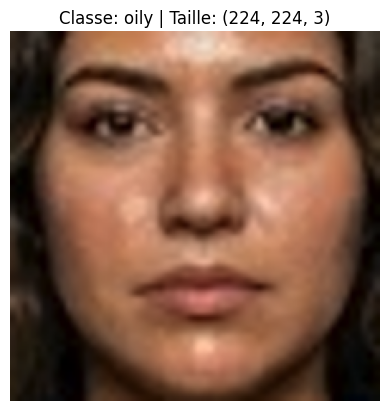

On voit un visage recadré en 224x224, c'est que tout fonctionne !


In [3]:
# --- CELLULE DE TEST VISUEL ---

# 1. On récupère une image de test (par exemple la première de la classe 'oily')
test_files = list(DATA_DIR.glob("oily/*.png")) + list(DATA_DIR.glob("oily/*.jpg"))
test_labels = [2] * len(test_files) # 2 est l'index pour 'oily'

# 2. On crée une instance de test sans "transform" complexe pour voir l'image brute
# On met augment=False pour ne pas avoir de flou aléatoire lors du test
dataset_test = SkinPreprocessing(test_files, test_labels, transform=transforms.ToTensor(), augment=False)

# 3. On récupère la première image traitée
img_tensor, label = dataset_test[0] # Cela appelle __getitem__

# 4. Affichage
img_to_show = img_tensor.permute(1, 2, 0).numpy() # On remet les dimensions pour matplotlib (H, W, C)
plt.imshow(img_to_show)
plt.title(f"Classe: {CLASSES[label]} | Taille: {img_to_show.shape}")
plt.axis('off')
plt.show()

print(f"On voit un visage recadré en 224x224, c'est que tout fonctionne !")

In [4]:
# Définition des augmentations (Géométrie et Couleur)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
# Récupération de tous les fichiers
all_files, all_labels = [], []
for idx, cls in enumerate(CLASSES):
    paths = list((DATA_DIR / cls).glob("*.png")) + list((DATA_DIR / cls).glob("*.jpg"))
    all_files.extend(paths)
    all_labels.extend([idx] * len(paths))

In [6]:
# Split 70% Train / 30% Val+Test
from sklearn.model_selection import train_test_split
train_f, temp_f, train_l, temp_l = train_test_split(all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
val_f, test_f, val_l, test_l = train_test_split(temp_f, temp_l, test_size=0.5, stratify=temp_l, random_state=42)

In [7]:
# Création des instances finales
train_dataset = SkinPreprocessing(train_f, train_l, transform=train_transforms, augment=True)
val_dataset = SkinPreprocessing(val_f, val_l, transform=val_transforms, augment=False)
test_dataset = SkinPreprocessing(test_f, test_l, transform=val_transforms, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

I0000 00:00:1776786952.646701 17439166 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1776786952.650380 17439168 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776786952.654804 17439175 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1776786952.656017 17439177 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1776786952.660260 17439184 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1776786952.661212 17439186 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [8]:
# 1. Chargement MobileNetV2
model = models.mobilenet_v2(weights='DEFAULT')
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_ftrs, 3))
model = model.to(DEVICE)

In [9]:
# 2. Optimisation
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[1].parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [10]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Stats
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


def evaluate_epoch(model, dataloader, criterion, device):
    """
    Évaluation légère utilisée à chaque epoch.
    Retourne uniquement (loss, accuracy, f1) sans aucun affichage.
    """
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            total_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = (all_preds == all_labels).mean()
    f1       = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1


def evaluate_full(model, dataloader, criterion, device, dataset_name="Validation"):
    """
    Évaluation complète post-entraînement.
    Affiche : métriques globales, rapport par classe, matrice de confusion.
    """
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            total_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = (all_preds == all_labels).mean()
    f1       = f1_score(all_labels, all_preds, average='weighted')

    # Métriques globales
    print(f"\n{'='*50}")
    print(f"  ÉVALUATION FINALE — {dataset_name.upper()}")
    print(f"{'='*50}")
    print(f"  Loss     : {avg_loss:.4f}")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  F1 (weighted) : {f1:.4f}")
    print(f"{'='*50}\n")

    # Rapport détaillé par classe
    print("Rapport détaillé par classe :")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Matrice de Confusion
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, colorbar=False)
    plt.title(f'Matrice de Confusion — {dataset_name}')
    plt.tight_layout()
    plt.show()

    return avg_loss, accuracy, f1

Lancement de l'entraînement sur cpu...
Epoch  1/15 | Train — Loss: 0.8863  Acc: 0.6256  F1: 0.8778 | Val   — Loss: 0.6559  Acc: 0.8467  F1: 0.8436
Epoch  2/15 | Train — Loss: 0.5941  Acc: 0.8674  F1: 0.9245 | Val   — Loss: 0.4594  Acc: 0.8905  F1: 0.8888
Epoch  3/15 | Train — Loss: 0.4574  Acc: 0.8970  F1: 0.9451 | Val   — Loss: 0.3808  Acc: 0.9051  F1: 0.9043
Epoch  4/15 | Train — Loss: 0.4082  Acc: 0.8939  F1: 0.9265 | Val   — Loss: 0.3317  Acc: 0.9197  F1: 0.9189
Epoch  5/15 | Train — Loss: 0.3527  Acc: 0.9158  F1: 0.9385 | Val   — Loss: 0.3036  Acc: 0.9124  F1: 0.9114
Epoch  6/15 | Train — Loss: 0.3555  Acc: 0.8955  F1: 0.9481 | Val   — Loss: 0.2930  Acc: 0.9051  F1: 0.9047
Epoch  7/15 | Train — Loss: 0.3129  Acc: 0.9080  F1: 0.9562 | Val   — Loss: 0.2710  Acc: 0.8832  F1: 0.8810
Epoch  8/15 | Train — Loss: 0.2792  Acc: 0.9345  F1: 0.9419 | Val   — Loss: 0.2443  Acc: 0.9124  F1: 0.9116
Epoch  9/15 | Train — Loss: 0.2554  Acc: 0.9360  F1: 0.9561 | Val   — Loss: 0.2366  Acc: 0.9051  

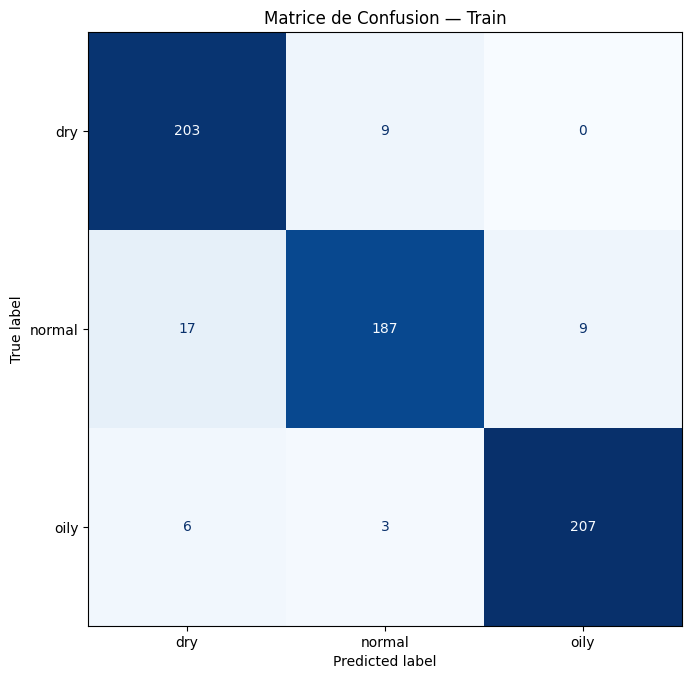


  ÉVALUATION FINALE — VALIDATION
  Loss     : 0.3317
  Accuracy : 0.9197
  F1 (weighted) : 0.9189

Rapport détaillé par classe :
              precision    recall  f1-score   support

         dry       0.89      0.91      0.90        45
      normal       0.91      0.85      0.88        46
        oily       0.96      1.00      0.98        46

    accuracy                           0.92       137
   macro avg       0.92      0.92      0.92       137
weighted avg       0.92      0.92      0.92       137



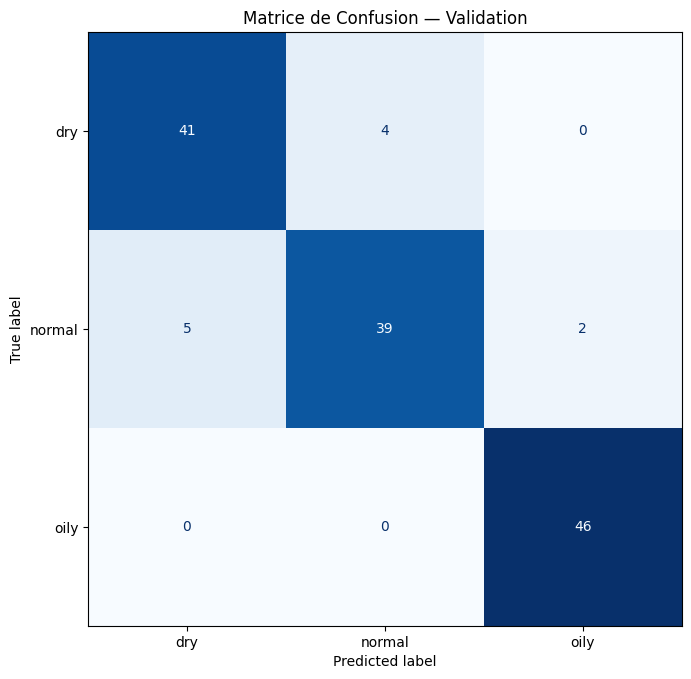

(0.3316606457216026, np.float64(0.9197080291970803), 0.9188710502683815)

In [12]:
import time
import copy

# ── Configuration de l'expérience ────────────────────────────────────────────
num_epochs     = 15
best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc   = 0.0

# Historique : loss, accuracy et F1 pour train ET val
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1':   []
}

print(f"Lancement de l'entraînement sur {DEVICE}...")
since = time.time()

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}

# ── Boucle principale ────────────────────────────────────────────────────────
for epoch in range(num_epochs):

    # Phase TRAIN
    train_loss, train_acc = train_one_epoch(
        model, dataloaders['train'], criterion, optimizer, DEVICE
    )

    # Phase EVAL train (légère — pas de plots)
    _, _, train_f1 = evaluate_epoch(
        model, dataloaders['train'], criterion, DEVICE
    )

    # Phase EVAL validation (légère — pas de plots)
    val_loss, val_acc, val_f1 = evaluate_epoch(
        model, dataloaders['val'], criterion, DEVICE
    )

    # Stockage dans l'historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(float(train_acc))
    history['train_f1'].append(float(train_f1))
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # Sauvegarde du meilleur modèle (val accuracy)
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:>2}/{num_epochs} | "
        f"Train — Loss: {train_loss:.4f}  Acc: {float(train_acc):.4f}  F1: {train_f1:.4f} | "
        f"Val   — Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}"
    )

# ── Bilan de l'entraînement ──────────────────────────────────────────────────
time_elapsed = time.time() - since
print(f'\nEntraînement terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Meilleure Accuracy en Validation : {best_val_acc:.4f}')

# ── Chargement des meilleurs poids ────────────────────────────────────────────
model.load_state_dict(best_model_wts)

# ── Évaluation finale complète : TRAIN puis VALIDATION ───────────────────────
evaluate_full(model, dataloaders['train'], criterion, DEVICE, "Train")
evaluate_full(model, dataloaders['val'],   criterion, DEVICE, "Validation")

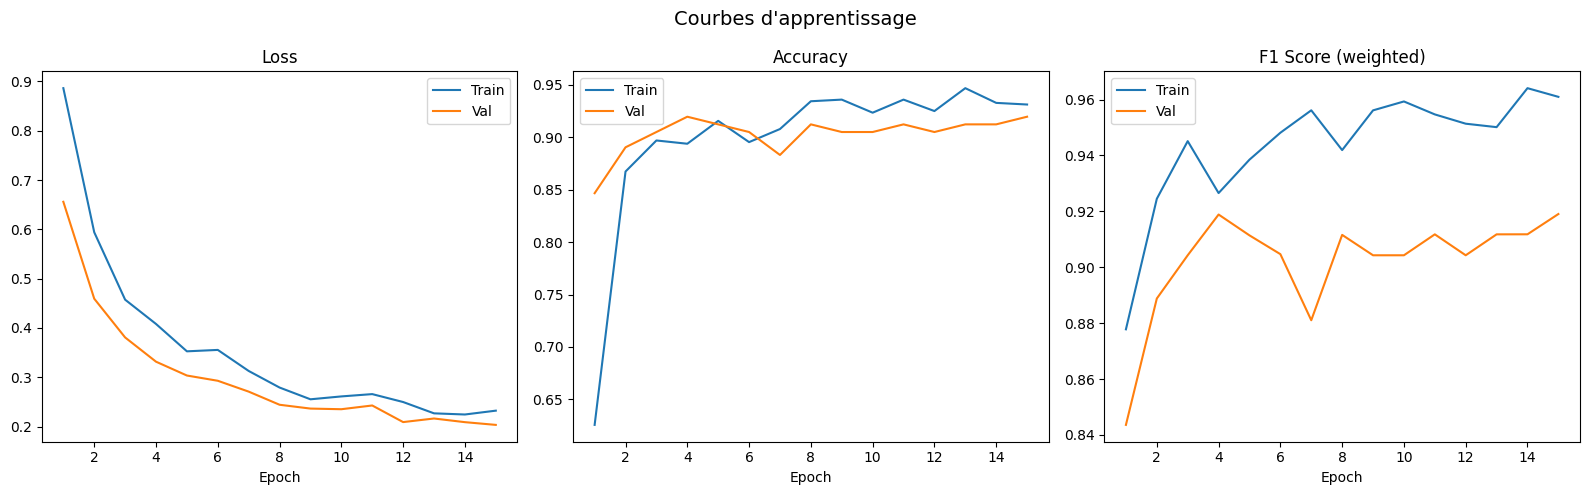

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
epochs_range = range(1, num_epochs + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# F1
axes[2].plot(epochs_range, history['train_f1'], label='Train')
axes[2].plot(epochs_range, history['val_f1'],   label='Val')
axes[2].set_title('F1 Score (weighted)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle("Courbes d'apprentissage", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
import torch
import os
from datetime import datetime

MODEL_DIR  = Path("../../oily/models")
MODEL_NAME = "mobilenetv2_generated_dataset_oily_dry_normal_v1"

os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Dossier modèles : {MODEL_DIR.resolve()}")

# Métadonnées de l'expérience
metadata = {
    "architecture"  : "MobileNetV2",
    "num_classes"   : len(CLASSES),
    "class_names"   : class_names,
    "best_val_acc"  : round(float(best_val_acc), 4),
    "epochs_trained": num_epochs,
    "date"          : datetime.now().strftime("%Y-%m-%d"),
    "notes"         : "New dataset in input, generated by AI, different preprocessing"
}

# Sauvegarde du checkpoint
checkpoint = {
    "model_state_dict"    : model.state_dict(),         # poids du modèle
    "optimizer_state_dict": optimizer.state_dict(),     # état de l'optimizer (utile pour reprendre l'entraînement)
    "history"             : history,                    # courbes d'apprentissage
    "metadata"            : metadata
}

save_path = os.path.join(MODEL_DIR, f"{MODEL_NAME}.pt")
torch.save(checkpoint, save_path)
print(f"Modèle sauvegardé : {save_path}")
print(f"Val Accuracy : {best_val_acc:.4f}")

Dossier modèles : /Users/ines.laguerre/Desktop/skinmatch/oily/models
Modèle sauvegardé : ../../oily/models/mobilenetv2_generated_dataset_oily_dry_normal_v1.pt
Val Accuracy : 0.9197


## Comparer avec la baseline entrainée sur le dataset Kaggle


              COMPARAISON SUR LE TEST SET               
Métrique             Baseline (Kaggle) Nouveau (Generated)
--------------------------------------------------------
Accuracy                        0.2971            0.9493  ✓
F1 (weighted)                   0.2215            0.9487  ✓


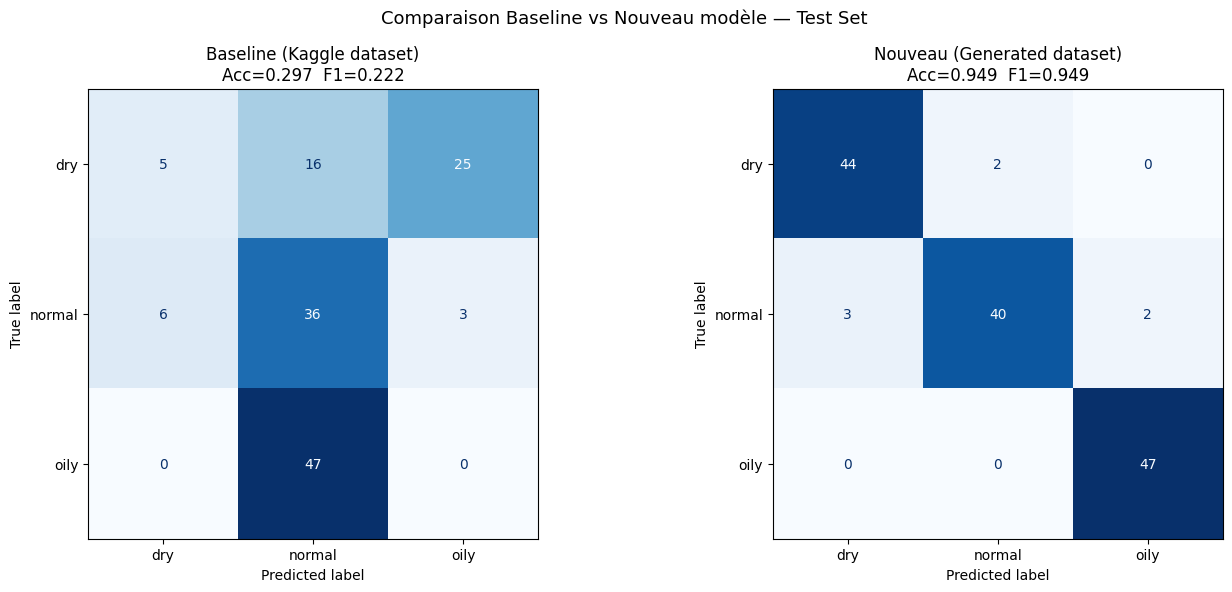

In [17]:
from sklearn.metrics import f1_score, accuracy_score

BASELINE_PATH = Path("../../oily/models/mobilenetv2_baseline_oily_dry_normal.pt")

# ── Chargement du modèle baseline ────────────────────────────────────────────
baseline_ckpt = torch.load(BASELINE_PATH, map_location=DEVICE, weights_only=False)

baseline_model = models.mobilenet_v2(weights=None)
num_ftrs = baseline_model.classifier[1].in_features
baseline_model.classifier[1] = nn.Linear(num_ftrs, 3)
baseline_model.load_state_dict(baseline_ckpt["model_state_dict"])
baseline_model = baseline_model.to(DEVICE)
baseline_model.eval()

# ── Fonction d'inférence brute ────────────────────────────────────────────────
def get_preds(m, loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            _, preds = torch.max(m(inputs), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

# ── Évaluation des deux modèles sur le test set ───────────────────────────────
new_preds,      new_labels      = get_preds(model,          test_loader)
baseline_preds, baseline_labels = get_preds(baseline_model, test_loader)

new_acc      = accuracy_score(new_labels,      new_preds)
baseline_acc = accuracy_score(baseline_labels, baseline_preds)
new_f1       = f1_score(new_labels,      new_preds,      average='weighted')
baseline_f1  = f1_score(baseline_labels, baseline_preds, average='weighted')

# ── Tableau comparatif ────────────────────────────────────────────────────────
print(f"\n{'='*56}")
print(f"{'COMPARAISON SUR LE TEST SET':^56}")
print(f"{'='*56}")
print(f"{'Métrique':<20} {'Baseline (Kaggle)':>17} {'Nouveau (Generated)':>17}")
print(f"{'-'*56}")
print(f"{'Accuracy':<20} {baseline_acc:>17.4f} {new_acc:>17.4f}  {'✓' if new_acc > baseline_acc else '✗'}")
print(f"{'F1 (weighted)':<20} {baseline_f1:>17.4f} {new_f1:>17.4f}  {'✓' if new_f1 > baseline_f1 else '✗'}")
print(f"{'='*56}")

# ── Matrices de confusion côte à côte ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, labels, title in [
    (axes[0], baseline_preds, baseline_labels, "Baseline (Kaggle dataset)"),
    (axes[1], new_preds,      new_labels,      "Nouveau (Generated dataset)"),
]:
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        cmap=plt.cm.Blues, values_format='d', ax=ax, colorbar=False
    )
    ax.set_title(f"{title}\nAcc={accuracy_score(labels, preds):.3f}  F1={f1_score(labels, preds, average='weighted'):.3f}")

plt.suptitle("Comparaison Baseline vs Nouveau modèle — Test Set", fontsize=13)
plt.tight_layout()
plt.show()